<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/03_modeling_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. Random Forest Model for Crop Suitability Prediction

In this notebook build a **Random Forest** classifier using the preprocessed data.
We will:
- Load the preprocessed training and test sets.
- Perform hyperparameter tuning with cross‑validation.
- Evaluate the best model on the test set.
- Plot the ROC curve and Precision‑Recall curve.
- Save the final model for later use.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             classification_report, confusion_matrix)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
%matplotlib inline

1. Load the Preprocessed Data

In [ ]:
# Load original data
df = pd.read_csv('Crop_training_data_FULL _1.csv')

# Separate features and target
X = df.drop(columns=['suitability', 'suitability_class', 'texture'])
y = df['suitability_class'].map({'Suitable': 1, 'Unsuitable': 0})

preprocessor = joblib.load('models/preprocessor.pkl')

X_processed = preprocessor.transform(X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1680, 30)
Test set size: (420, 30)


2. Baseline Random Forest

In [ ]:
rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)
y_proba_default = rf_default.predict_proba(X_test)[:, 1]

print("Default Random Forest Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_default))
print("Precision:", precision_score(y_test, y_pred_default))
print("Recall   :", recall_score(y_test, y_pred_default))
print("F1-score :", f1_score(y_test, y_pred_default))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_default))

Default Random Forest Performance:
Accuracy : 0.7785714285714286
Precision: 0.7770700636942676
Recall   : 0.9138576779026217
F1-score : 0.8399311531841652
ROC-AUC  : 0.839036988078627


3. Hyperparameter Tuning with GridSearchCV

In [ ]:
# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Random Forest classifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation ROC-AUC: {:.4f}".format(grid_search.best_score_))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best cross-validation ROC-AUC: 0.8837


4. Evaluate Best Model on Test Set

In [ ]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("Test Set Performance:")
print("Accuracy : {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred)))
print("Recall   : {:.4f}".format(recall_score(y_test, y_pred)))
print("F1-score : {:.4f}".format(f1_score(y_test, y_pred)))
print("ROC-AUC  : {:.4f}".format(roc_auc_score(y_test, y_proba)))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Unsuitable', 'Suitable']))

Test Set Performance:
Accuracy : 0.7929
Precision: 0.7961
Recall   : 0.9064
F1-score : 0.8476
ROC-AUC  : 0.8497

Classification Report:
              precision    recall  f1-score   support

  Unsuitable       0.78      0.59      0.68       153
    Suitable       0.80      0.91      0.85       267

    accuracy                           0.79       420
   macro avg       0.79      0.75      0.76       420
weighted avg       0.79      0.79      0.79       420



5. Confusion Matrix

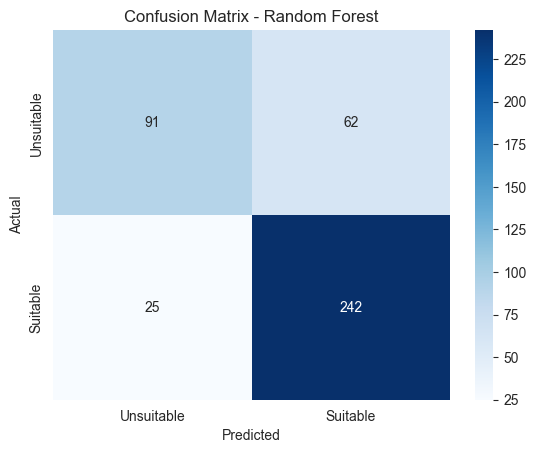

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unsuitable', 'Suitable'],
            yticklabels=['Unsuitable', 'Suitable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

6. ROC Curve

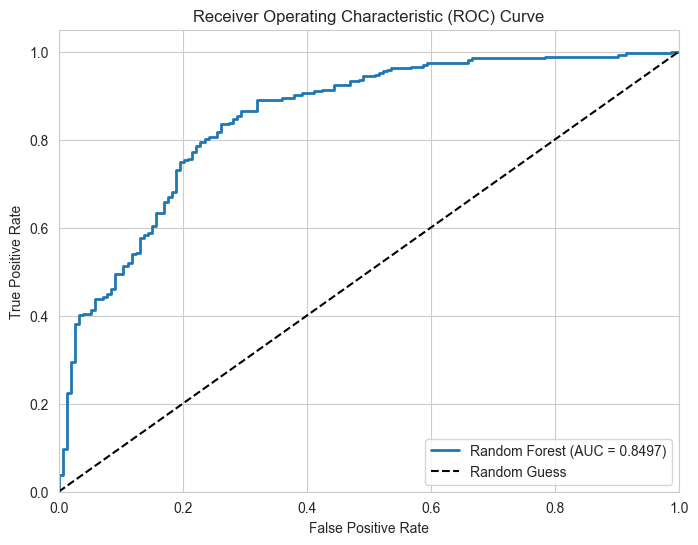

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.4f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

7. Precision‑Recall Curve

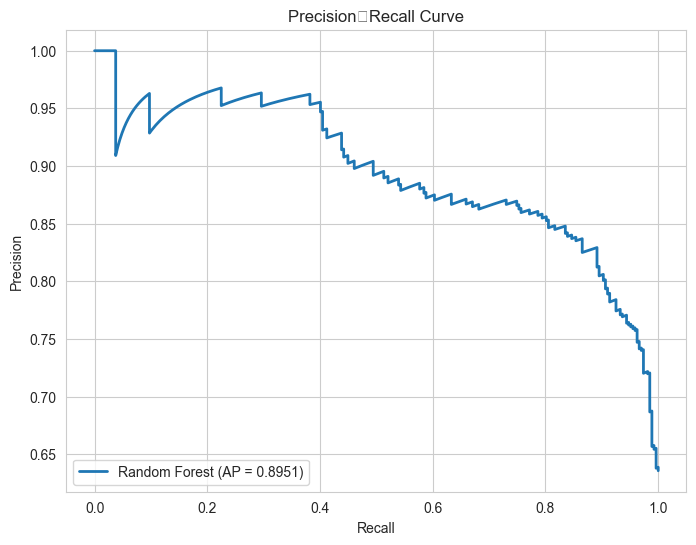

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = roc_auc_score(y_test, y_proba)
from sklearn.metrics import average_precision_score
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Random Forest (AP = {ap:.4f})', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

8. Feature Importance

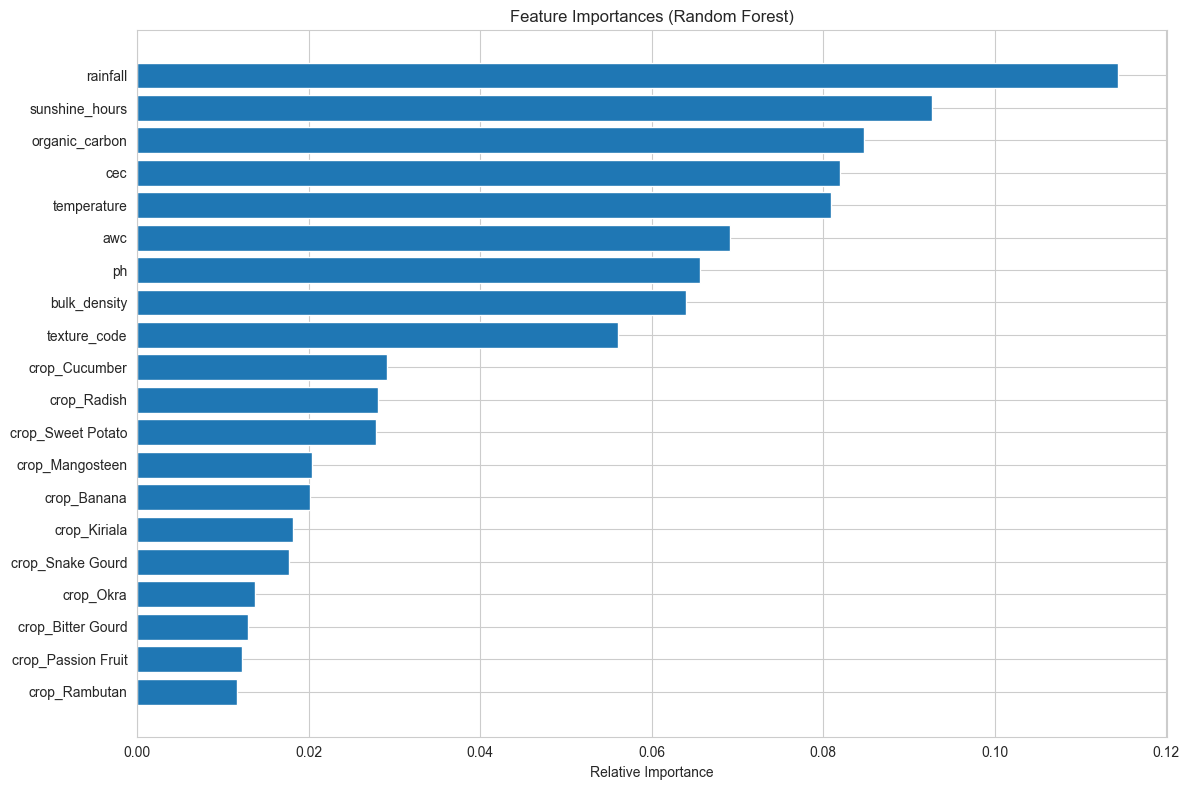

In [ ]:
# Get feature names after preprocessing
num_features = ['temperature', 'rainfall', 'sunshine_hours', 'ph',
                'organic_carbon', 'cec', 'awc', 'bulk_density',
                 'texture_code']
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(['crop'])
all_features = np.concatenate([num_features, cat_features])

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importances (Random Forest)")
plt.barh(range(20), importances[indices][:20], align='center')
plt.yticks(range(20), all_features[indices][:20])
plt.gca().invert_yaxis()
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Save the trained Random Forest model
joblib.dump(best_rf, 'models/random_forest_best.pkl')
print("Model saved to ../models/random_forest_best.pkl")

Model saved to ../models/random_forest_best.pkl
